# Imports

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import tempfile
from pathlib import Path
import copy
import random
import hashlib
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import userdata


# Device Config
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
def send_to_gpu(*vars):
    # Sends all provided variables to GPU
    if torch.cuda.is_available():
        device = torch.device("cuda")
        moved = [v.to(device) for v in vars]
        return moved[0] if len(moved) == 1 else moved
    else:
        raise Exception("CUDA not available")

# Load Data


In [3]:
os.environ['KAGGLE_USERNAME'] = userdata.get('username')
os.environ['KAGGLE_KEY'] = userdata.get('key')
os.environ['RAY_PICKLE_VERBOSE_DEBUG'] = '1'

!kaggle competitions download -c ecse-551-assignment-2-image-classification > /dev/null 2>&1
!unzip ecse-551-assignment-2-image-classification.zip > /dev/null 2>&1

!rm ecse-551-assignment-2-image-classification.zip

print("Downloaded and extracted dataset.")

Downloaded and extracted dataset.


# Image Dataset

In [4]:
class ImageDataset(Dataset):
    def __init__(self, df, img_dir,
                 transform=None,
                 ):
        """
        labels: pandas DataFrame with ['id', 'label']
        img_dir: path to image directory
        target_size: resize target (H, W) --> Standard is 32x32
        normalize_range: "0-1", "-1-1", or None
        """
        self.labels = df['label'].astype(str)

        # reset indices accordingly.
        self.df = df.reset_index(drop=True)

        self.img_dir = img_dir

        self.transform = transform

        # indexing with unique image names
        self.classes = sorted(self.labels.unique().tolist())
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx, 0]
        label = self.df.iloc[idx, 1]

        img_path = os.path.abspath(os.path.join(self.img_dir, img_name))
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        label_idx = self.class_to_idx[label]

        # --- CHANGE: Return idx as the 3rd element ---
        return image, label_idx, idx

In [5]:
train_transform = transforms.Compose([
    transforms.Resize(160),
    transforms.RandomCrop(128),
    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(15),      # Rotates image +/- 15 degrees
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), # Changes lighting
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)), # Shifts image slightly

    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

val_transform = transforms.Compose([
    transforms.Resize(128),  # Resize to 128x128 for validation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])


In [6]:
img_dir='kaggle_challenge/train'
labels_csv_file='kaggle_challenge/train_labels.csv'
labels_df = pd.read_csv(labels_csv_file)
num_classes = labels_df['label'].nunique()

val_ratio = 0.2 # Default Value
# Using Stratified fold instead to preserve class balance
train_df, val_df = train_test_split(
    labels_df,
    test_size=val_ratio,
    stratify=labels_df['label'],
    random_state=42
)

In [7]:
train_df = ImageDataset(train_df, img_dir=img_dir, transform=train_transform)
val_df = ImageDataset(val_df, img_dir=img_dir, transform=val_transform)

# CNN

## Model

### Residual Block class


In [8]:
class ResidualBlock(nn.Module):
    """
    Implements y = f(x) + x
    If input channels != output channels, we apply a 1x1 conv to x
    so dimensions match for the addition.
    """
    def __init__(self, in_c, out_c, kernel_size, norm_type, act_name, dropout_p):
        super().__init__()

        # Main Path (The "Convolutions")
        self.conv1 = nn.Conv2d(in_c, out_c, kernel_size, padding=kernel_size//2, bias=False)
        self.norm1 = _make_norm(norm_type, out_c)
        self.act1  = _act(act_name)

        self.conv2 = nn.Conv2d(out_c, out_c, kernel_size, padding=kernel_size//2, bias=False)
        self.norm2 = _make_norm(norm_type, out_c)
        self.act2  = _act(act_name)

        self.dropout = nn.Dropout(dropout_p) if dropout_p > 0 else nn.Identity()

        # Shortcut Path (The "Skip Connection")
        self.shortcut = nn.Sequential()
        if in_c != out_c:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=1, bias=False), # 1x1 Conv to match channels
                _make_norm(norm_type, out_c)
            )

    def forward(self, x):
        residual = x # Save input

        # Pass through main layers
        out = self.act1(self.norm1(self.conv1(x)))
        out = self.dropout(out)
        out = self.norm2(self.conv2(out))

        # --- THE RESIDUAL CONNECTION ---
        # Add original input (passed through 1x1 conv if necessary)
        out += self.shortcut(residual)

        # Final activation after addition
        out = self.act2(out)
        return out

### Mixup Cutmix

In [9]:
def rand_bbox(size, lam):
    """Generates a random box for CutMix"""
    W = size[2]
    H = size[3]
    cut_rat = np.sqrt(1. - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)

    # Uniform center
    cx = np.random.randint(W)
    cy = np.random.randint(H)

    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)

    return bbx1, bby1, bbx2, bby2

def cutmix_data(data, targets, alpha=1.0):
    """Applies CutMix to a batch."""
    indices = torch.randperm(data.size(0)).to(data.device)
    shuffled_data = data[indices]
    shuffled_targets = targets[indices]

    lam = np.random.beta(alpha, alpha)
    bbx1, bby1, bbx2, bby2 = rand_bbox(data.size(), lam)

    # Replace patch
    data[:, :, bbx1:bbx2, bby1:bby2] = data[indices, :, bbx1:bbx2, bby1:bby2]

    # Adjust lambda to exactly match pixel ratio
    lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (data.size()[-1] * data.size()[-2]))

    return data, targets, shuffled_targets, lam

def mixup_data(x, y, alpha=1.0):
    """Applies Mixup to a batch."""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

### Alternating Flip

In [10]:
def hash_fn(n, seed=42):
    k = n * seed
    return int(hashlib.md5(bytes(str(k), 'utf-8')).hexdigest()[-8:], 16)

def alternating_flip(inputs, indices, epoch):
    """Flipping that is deterministic per image/epoch"""
    # Hash indices to get a fixed random pattern per image
    hashed_indices = torch.tensor([hash_fn(i.item()) for i in indices]).to(inputs.device)

    # Flip if (hash + epoch) is even
    flip_mask = ((hashed_indices + epoch) % 2 == 0).view(-1, 1, 1, 1)

    return torch.where(flip_mask, inputs.flip(-1), inputs)

### Main CNN Class

In [11]:
def _make_norm(norm_type: str, num_channels: int, groups: int = 2):
    norm_type = norm_type.lower()
    if norm_type == "batch": return nn.BatchNorm2d(num_channels)
    if norm_type == "layer": return nn.GroupNorm(1, num_channels)
    if norm_type == "instance": return nn.InstanceNorm2d(num_channels, affine=True)
    if norm_type == "none": return nn.Identity()
    raise ValueError("Unsupported norm_type")

def _act(name: str):
    name = name.lower()
    if name == "relu":
        return nn.ReLU(inplace=True)
    elif name == "silu":
        return nn.SiLU(inplace=True)
    elif name == "gelu":
        return nn.GELU()
    elif name == "leaky_relu":
        return nn.LeakyReLU(negative_slope=0.01, inplace=True)
    else:
        raise ValueError(f"Activation '{name}' is not supported.")

class CNNClassifier(nn.Module):
    def __init__(self, config, num_classes=10):
        super().__init__()
        self.num_classes = num_classes

        # HParams
        self.num_blocks = config.get("num_blocks", 3)
        self.dropout_p = config.get("dropout_p", 0.2)
        self.activation = config.get("activation", "relu")
        self.norm_type = config.get("norm_type", "batch")
        kernel_size = config.get("kernel_size", 3)

        # Architecture Definition
        self.channels_per_block = [32, 64, 128, 256, 512, 512, 512][:self.num_blocks]

        self.features = self._build_features(kernel_size)
        self.classifier = self._build_classifier()

    def _build_features(self, kernel_size):
        layers = []
        c_in = 3 # Input is RGB

        for out_c in self.channels_per_block:
            # Add our new Residual Block
            layers.append(
                ResidualBlock(c_in, out_c, kernel_size, self.norm_type, self.activation, self.dropout_p)
            )
            # Downsample after the block
            layers.append(nn.MaxPool2d(2))
            c_in = out_c

        return nn.Sequential(*layers)

    def _build_classifier(self):
        last_c = self.channels_per_block[-1]
        return nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(last_c, self.num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

    # --- STATIC TRAINING FUNCTION ---
    @staticmethod
    def train_model(config, train_dataset, val_dataset, device, history=None, epochs=15, start_weights=None):
        train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True, num_workers=2)
        val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=False, num_workers=2)

        # 1. Initialize Model
        model = CNNClassifier(config, num_classes=10)
        if start_weights is not None:
            model.load_state_dict(start_weights)
            print("Loaded previous weights. Resuming training...")
        model = model.to(device)

        # 2. Setup Optimizer with Weight Decay
        weight_decay = config.get('weight_decay', 0.0)

        criterion = nn.CrossEntropyLoss(label_smoothing=0.2)
        optimizer = optim.Adam(model.parameters(), lr=config['lr'], weight_decay=weight_decay)

        # Scheduler: uses the 'patience' argument passed to the function
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
          optimizer,
          mode='max',
          factor=0.5,
          patience=config.get('patience', 5)
          )

        # Extract Mixup params from config here
        # This ensures it respects the parameters you are tuning
        mix_prob = config.get('mix_prob', 0.5)
        mix_alpha = config.get('mix_alpha', 1.0)

        best_val_acc = 0.0
        best_model_state = None

        # Renamed to avoid conflict with scheduler 'patience'
        early_stop_patience = 20
        trigger_times = 0

        # Initialize history if it wasn't provided
        if history is None:
            history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

        for epoch in range(epochs):
            # TRAINING
            model.train()
            train_running_loss = 0.0
            train_correct = 0
            train_total = 0

            # Unpack 'indices' from loader
            for inputs, labels, indices in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                # ALTERNATING FLIP LOGIC
                # Epoch 0: Random Flip (Warmup)
                if epoch == 0:
                    if np.random.rand() < 0.5: inputs = inputs.flip(-1)
                # Epoch > 0: Deterministic Alternating Flip
                else:
                    inputs = alternating_flip(inputs, indices, epoch)

                optimizer.zero_grad()

                #  Use the variables extracted from config
                # Randomly decide to mix based on config['mix_prob']
                if np.random.rand() < mix_prob:
                    # Decide between Mixup vs CutMix (50/50)
                    if np.random.rand() < 0.5:
                        inputs, targets_a, targets_b, lam = mixup_data(inputs, labels, mix_alpha)
                    else:
                        inputs, targets_a, targets_b, lam = cutmix_data(inputs, labels, mix_alpha)

                    # Forward pass with Mixed Images
                    outputs = model(inputs)

                    # Calculate Mixed Loss
                    loss = lam * criterion(outputs, targets_a) + (1 - lam) * criterion(outputs, targets_b)

                else:
                    # Standard Training
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                loss.backward()
                optimizer.step()

                train_running_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                train_total += labels.size(0)
                train_correct += (predicted == labels).sum().item()

            epoch_train_loss = train_running_loss / train_total
            epoch_train_acc = 100 * train_correct / train_total

            # VALIDATION
            model.eval()
            val_running_loss = 0.0
            val_correct = 0
            val_total = 0

            with torch.no_grad():
                for inputs, labels, _ in val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    val_running_loss += loss.item() * inputs.size(0)
                    _, predicted = torch.max(outputs.data, 1)
                    val_total += labels.size(0)
                    val_correct += (predicted == labels).sum().item()

            epoch_val_loss = val_running_loss / val_total
            epoch_val_acc = 100 * val_correct / val_total

            # 1. Get LR before update
            prev_lr = optimizer.param_groups[0]['lr']

            # 2. Step the scheduler
            scheduler.step(epoch_val_acc)

            # 3. Get LR after update
            current_lr = optimizer.param_groups[0]['lr']

            # 4. Print Alert if changed
            if current_lr < prev_lr:
                print(f"LR DROPPED at epoch: {epoch+1}: {prev_lr:.1e} -> {current_lr:.1e}")

            # Append to history
            history['train_loss'].append(epoch_train_loss)
            history['train_acc'].append(epoch_train_acc)
            history['val_loss'].append(epoch_val_loss)
            history['val_acc'].append(epoch_val_acc)

            print(f"Epoch {epoch+1}/{epochs} | "
                  f"Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.2f}% | "
                  f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.2f}%")

            if epoch_val_acc > best_val_acc:
                best_val_acc = epoch_val_acc
                best_model_state = copy.deepcopy(model.state_dict())
                trigger_times = 0
            else:
                trigger_times += 1
                if trigger_times >= early_stop_patience:
                    print(f"Early stopping at epoch {epoch+1}")
                    break

        return best_val_acc, best_model_state, history

## Model Training



### Set-up

In [24]:
weights = None
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

### HPO

In [ ]:
# Define the Broad Search Space
param_dist = {
    # Architecture
    'num_blocks': [6, 7],             # Verify depth choice
    'activation': ['relu', 'gelu', 'leaky_relu'],

    # Optimization
    'lr': lambda: 10 ** np.random.uniform(-4, -2.5), # Log-uniform [1e-4, 3e-3]
    'batch_size': [32, 64],
    'patience': [3, 5],               # Scheduler patience

    # Regularization
    'dropout_p': lambda: np.random.uniform(0.1, 0.4),
    'weight_decay': lambda: 10 ** np.random.uniform(-5, -3), # [1e-5, 1e-3]

    # Augmentation
    'mix_prob': [0.3, 0.5, 0.7],      # How often to mix
    'mix_alpha': [0.4, 1.0]           # 1.0 = linear, 0.4 = biased towards one image
}

def get_random_config():
    config = {}
    for key, value in param_dist.items():
        if callable(value):
            config[key] = value()
        else:
            config[key] = random.choice(value)
    return config

# Run the HPO Loop
NUM_TRIALS = 20   # 20 trials
EPOCHS = 12       # Short runs to check "learning speed" and stability

results = []

print(f"Starting Comprehensive Random Search ({NUM_TRIALS} Trials)...")

for i in range(NUM_TRIALS):
    config = get_random_config()

    # Ensure mandatory static params are present
    config['norm_type'] = 'batch'

    print(f"\n>>> Trial {i+1}/{NUM_TRIALS}")
    print(f"    Config: {config}")

    try:
        # Train
        acc, _, history = CNNClassifier.train_model(
            config, train_df, val_df, device, epochs=EPOCHS
        )

        # Log Result
        entry = config.copy()
        entry['trial_id'] = i+1
        entry['best_val_acc'] = acc
        entry['final_train_acc'] = history['train_acc'][-1]
        results.append(entry)

        print(f"    Result: {acc:.2f}% Val Accuracy")

    except Exception as e:
        print(f"    Trial failed: {e}")

# Save & Display Data
df = pd.DataFrame(results)
df.to_csv("hpo_comprehensive_results.csv", index=False)

print("\nTOP 5 CONFIGURATIONS:")
print(df.sort_values(by='best_val_acc', ascending=False).head(5))

Starting Comprehensive Random Search (20 Trials)...

>>> Trial 1/20
    Config: {'num_blocks': 7, 'activation': 'leaky_relu', 'lr': 0.0014222296910711555, 'batch_size': 64, 'patience': 5, 'dropout_p': 0.19403356764759422, 'weight_decay': 3.300030917332072e-05, 'mix_prob': 0.7, 'mix_alpha': 0.4, 'norm_type': 'batch'}
Epoch 1/12 | Train Loss: 2.1568 Acc: 19.23% | Val Loss: 1.8730 Acc: 29.80%
Epoch 2/12 | Train Loss: 2.0042 Acc: 22.43% | Val Loss: 1.7601 Acc: 32.75%
Epoch 3/12 | Train Loss: 1.9421 Acc: 25.88% | Val Loss: 1.6597 Acc: 36.55%
Epoch 4/12 | Train Loss: 1.8509 Acc: 29.88% | Val Loss: 1.5812 Acc: 42.05%
Epoch 5/12 | Train Loss: 1.7927 Acc: 34.61% | Val Loss: 1.7305 Acc: 41.10%
Epoch 6/12 | Train Loss: 1.7310 Acc: 34.71% | Val Loss: 1.8283 Acc: 36.50%
Epoch 7/12 | Train Loss: 1.6630 Acc: 38.25% | Val Loss: 1.3487 Acc: 52.45%
Epoch 8/12 | Train Loss: 1.6093 Acc: 40.12% | Val Loss: 1.5020 Acc: 50.95%
Epoch 9/12 | Train Loss: 1.5491 Acc: 39.20% | Val Loss: 1.9822 Acc: 41.30%
Epoch 1

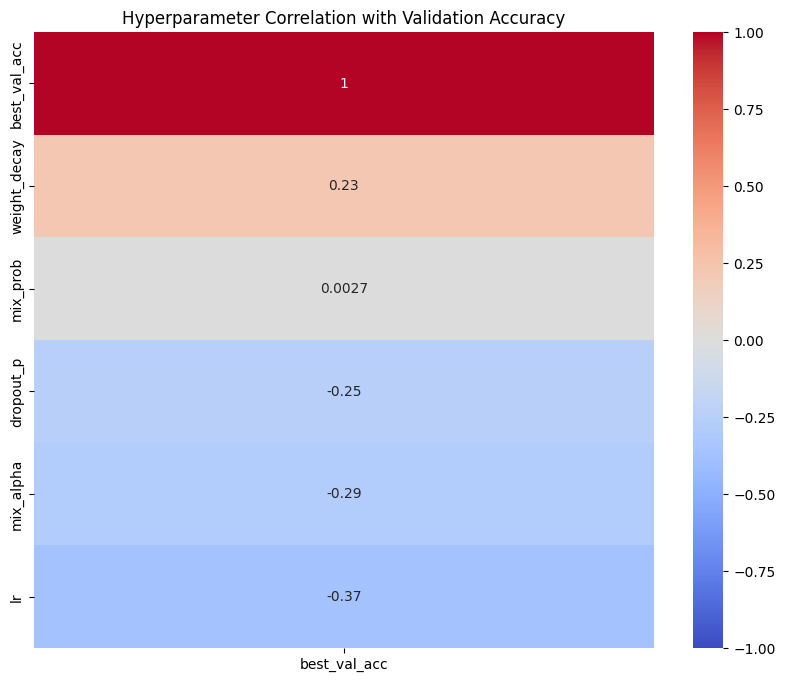

In [ ]:
# Create a correlation heatmap
plt.figure(figsize=(10, 8))

# Select only numeric columns for correlation
numeric_cols = ['lr', 'dropout_p', 'weight_decay', 'mix_prob', 'mix_alpha', 'best_val_acc']
corr_df = df[numeric_cols]

# Plot
sns.heatmap(corr_df.corr()[['best_val_acc']].sort_values(by='best_val_acc', ascending=False),
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Hyperparameter Correlation with Validation Accuracy")
plt.show()

## Best Model after HPO

In [12]:
final_hero_config = {
    # --- Architecture
    'num_blocks': 7,
    'activation': 'gelu',    # GELU performed best for 7 blocks
    'norm_type': 'batch',

    # --- Optimization
    'lr': 2.2e-4,            # Precision from HPO
    'batch_size': 64,        # 64 consistently beat 32
    'patience': 5,           # Keep scheduler patience at 5 for the long run

    # --- Regularization
    'dropout_p': 0.11,       # Keep extremely low
    'weight_decay': 4.7e-4,  # Trial 16 preferred this specific value

    # --- Augmentation
    'mix_prob': 0.7,         # High mixing for the deep model
    'mix_alpha': 0.4         # 0.4 was used in 4 of the top 5 configs
}

In [61]:
acc, weights, history = CNNClassifier.train_model(
            final_hero_config, train_df, val_df, device, epochs=80, start_weights = weights,
            history = history
        )

Epoch 1/80 | Train Loss: 2.3583 Acc: 22.05% | Val Loss: 2.1096 Acc: 31.80%
Epoch 2/80 | Train Loss: 2.1007 Acc: 28.90% | Val Loss: 1.8568 Acc: 42.10%
Epoch 3/80 | Train Loss: 2.0534 Acc: 29.64% | Val Loss: 1.8318 Acc: 45.75%
Epoch 4/80 | Train Loss: 2.0153 Acc: 33.49% | Val Loss: 1.7993 Acc: 46.45%
Epoch 5/80 | Train Loss: 1.9814 Acc: 33.35% | Val Loss: 1.7416 Acc: 51.60%
Epoch 6/80 | Train Loss: 1.9323 Acc: 36.26% | Val Loss: 1.7097 Acc: 52.45%
Epoch 7/80 | Train Loss: 1.8816 Acc: 41.73% | Val Loss: 1.6464 Acc: 57.10%
Epoch 8/80 | Train Loss: 1.8567 Acc: 41.58% | Val Loss: 1.6347 Acc: 59.20%
Epoch 9/80 | Train Loss: 1.8510 Acc: 42.75% | Val Loss: 1.6051 Acc: 60.85%
Epoch 10/80 | Train Loss: 1.7940 Acc: 41.26% | Val Loss: 1.5845 Acc: 61.85%
Epoch 11/80 | Train Loss: 1.7918 Acc: 46.31% | Val Loss: 1.5526 Acc: 64.40%
Epoch 12/80 | Train Loss: 1.7694 Acc: 48.10% | Val Loss: 1.5594 Acc: 63.00%
Epoch 13/80 | Train Loss: 1.7462 Acc: 48.51% | Val Loss: 1.4883 Acc: 68.40%
Epoch 14/80 | Train L

In [62]:
model = CNNClassifier(config = final_hero_config, num_classes=10)
torch.save(weights, "HERO_FINAL_82_PERCENT.pth")
model.load_state_dict(torch.load("HERO_FINAL_82_PERCENT.pth"))




<All keys matched successfully>

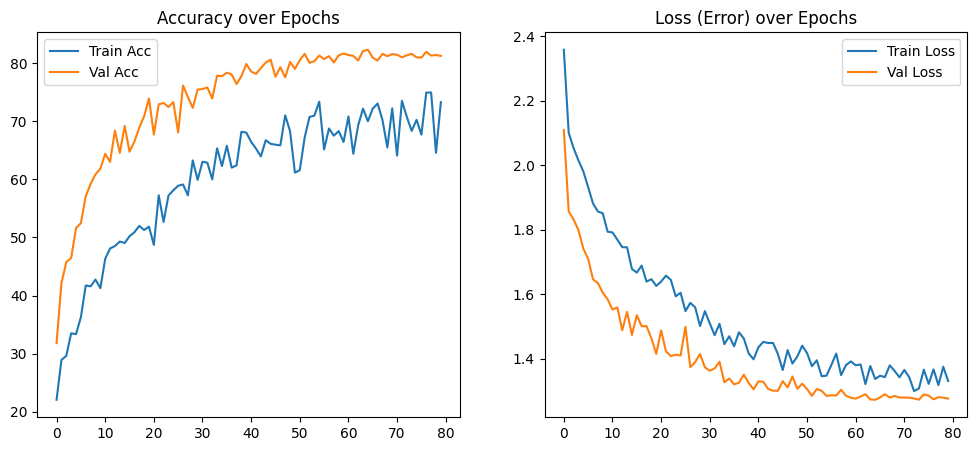

In [63]:
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss (Error) over Epochs')
plt.legend()

plt.show()

# Kaggle test

In [64]:
class KaggleTestDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        # List all files
        self.img_names = [f for f in os.listdir(img_dir) if f.endswith('.jpg') or f.endswith('.png')]

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        img_name = self.img_names[idx]
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        # Extract ID (remove extension) for the CSV
        img_id = os.path.splitext(img_name)[0]
        return image, img_id

In [75]:
# Setup Data & Mapping
test_dir = 'kaggle_challenge/test'

# Reconstruct the Class Mapping
labels_df = pd.read_csv('kaggle_challenge/train_labels.csv')
classes = sorted(labels_df['label'].unique().tolist())
idx_to_class = {idx: cls for idx, cls in enumerate(classes)}

# Create Test Loader
test_dataset = KaggleTestDataset(test_dir, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

# Load Model
model = CNNClassifier(config=final_hero_config, num_classes=10)
model = model.to(device)
model.load_state_dict(torch.load("HERO_FINAL_82_PERCENT.pth"))
model = model.to(device)
model.eval()

# Prediction Loop
print(f"Predicting on {len(test_dataset)} test images...")

predictions = []
ids = []

with torch.no_grad():
    for inputs, img_ids in test_loader:
        inputs = inputs.to(device)

        # Standard Prediction
        outputs = model(inputs)

        # Optional TTA (Uncomment if needed)
        # outputs = (outputs + model(inputs.flip(-1))) / 2

        _, preds = torch.max(outputs, 1)

        predictions.extend(preds.cpu().numpy())
        ids.extend(img_ids)

# Create Submission CSV
# Map numeric predictions back to string labels
predicted_labels = [idx_to_class[p] for p in predictions]

submission_df = pd.DataFrame({
    # CHANGE: Use list comprehension to append .png to every ID
    'id': [f"{x}.png" for x in ids],
    'label': predicted_labels
})

submission_df.to_csv("submission.csv", index=False)
print("Success! Saved to 'submission.csv'")
print(submission_df.head())

Predicting on 2000 test images...
Success! Saved to 'submission.csv'
          id  label
0  01605.png    dog
1  00631.png    dog
2  00150.png   ship
3  01723.png  horse
4  00440.png   frog


# Misclassification Visualization


In [14]:
val_loader = DataLoader(val_df, batch_size=64, shuffle=False, num_workers=2)

# Setup Model
model = CNNClassifier(config=final_hero_config, num_classes=10)
model = model.to(device)
model.load_state_dict(torch.load("HERO_FINAL_82_PERCENT.pth"))
model.eval()

# Collect Predictions
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels, _ in val_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

/tmp/ipython-input-1775073663.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


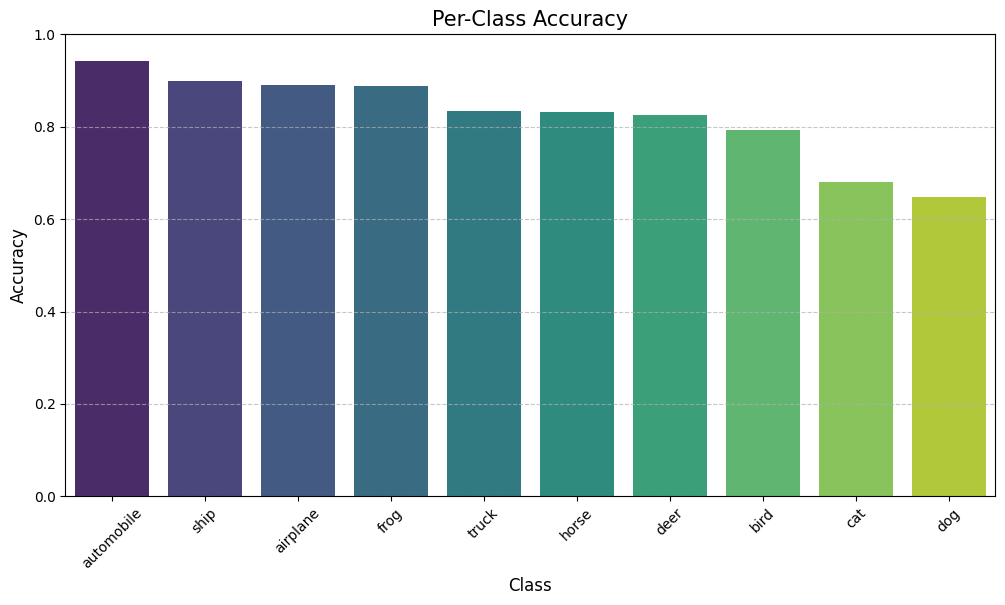

In [15]:
# Map classes (same as before)
idx_to_class = {i: cls for i, cls in enumerate(val_df.classes)}

# --- Build DataFrame ---
results_df = pd.DataFrame({
    'true_idx': all_labels,
    'pred_idx': all_preds
})

results_df['true_label'] = results_df['true_idx'].map(idx_to_class)
results_df['pred_label'] = results_df['pred_idx'].map(idx_to_class)
# --- Compute Per-Class Accuracy ---
class_stats = []

for cls_idx, cls_name in idx_to_class.items():
    cls_df = results_df[results_df['true_idx'] == cls_idx]

    total = len(cls_df)
    correct = (cls_df['true_idx'] == cls_df['pred_idx']).sum()
    accuracy = correct / total if total > 0 else 0.0

    class_stats.append({
        'class': cls_name,
        'accuracy': accuracy
    })

accuracy_df = pd.DataFrame(class_stats).sort_values(by='accuracy', ascending=False)

# --- Plot ---
plt.figure(figsize=(12, 6))
sns.barplot(
    data=accuracy_df,
    x='class',
    y='accuracy',
    palette='viridis'
)
plt.title("Per-Class Accuracy", fontsize=15)
plt.xlabel("Class", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

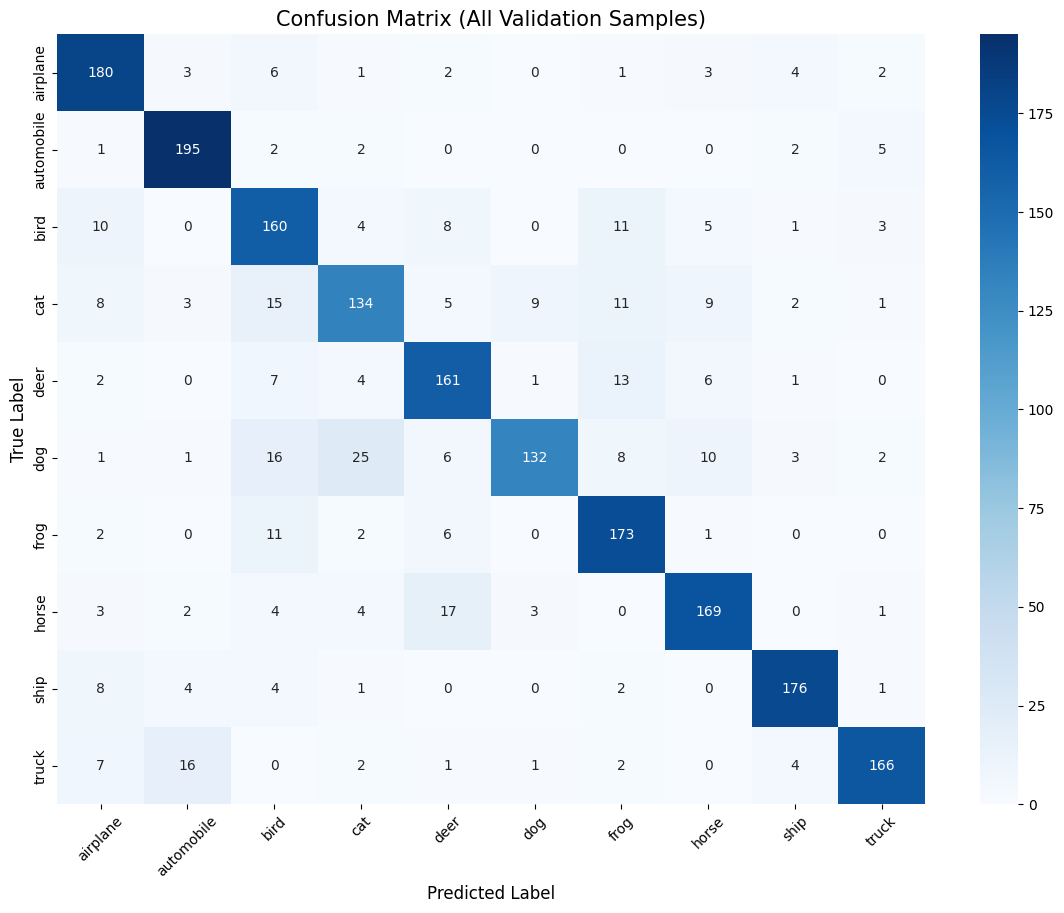

In [16]:
# Confusion Matrix of Errors
plt.figure(figsize=(14, 10))

# Calculate confusion matrix for ALL data (to normalize correctly)
cm = confusion_matrix(all_labels, all_preds)

# Create a heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=val_df.classes,
    yticklabels=val_df.classes
)
plt.title('Confusion Matrix (All Validation Samples)', fontsize=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45)
plt.show()